In [3]:
from IPython.display import HTML, Javascript, display

display(HTML("""
<style>
a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* markdown tabela – zadrži staro ponašanje */
table:not(.dataframe) tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* dataframe – samo pravo zaglavlje */
table.dataframe thead tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* index kolona dataframe da ne bude bold */
table.dataframe tbody th {
    font-weight: normal !important;
}

/* linija ispod poslednjeg reda */
tbody tr:last-child td,
tbody tr:last-child th {
    border-bottom: 1px solid #aaa !important;
}

/* caption */
caption,
.table-caption,
p.caption,
div.caption,
figcaption {
    text-align: center !important;
    font-weight: bold !important;
}
</style>
"""))

display(Javascript("""
function promeniTableUTabela() {
    const selectors = [
        "caption",
        ".table-caption",
        "p.caption",
        "div.caption",
        "figcaption",
        ".caption-number"
    ];

    document.querySelectorAll(selectors.join(",")).forEach(function(el) {
        if (el.innerHTML.includes("Table")) {
            el.innerHTML = el.innerHTML.replace(/\\bTable\\b/g, "Tabela");
        }
    });
}

promeniTableUTabela();

/* ako se notebook kasnije rerenderuje */
const observer = new MutationObserver(function() {
    promeniTableUTabela();
});

observer.observe(document.body, {
    childList: true,
    subtree: true
});
"""))

<IPython.core.display.Javascript object>

# Naivni Bajesovi klasifikatori
<br>
Naivni Bajesov metod predstavlja jednostavan, ali izuzetno efikasan probabilistički model za klasifikaciju zasnovan na Bajesovoj teoremi. Osnovna ideja modela je procena verovatnoće pripadnosti određenoj klasi na osnovu posmatranih karakteristika.


**Ishodi učenja**: Nakon proučavanja ovog poglavlja student će biti u stanju da:
- objasni osnovni princip Naivnog Bajesovog metoda i njegovu vezu sa Bajesovom teoremom  
- interpretira pretpostavku uslovne nezavisnosti  
- primeni Naivni Bajesov klasifikator
- analizira rezultate klasifikacije i donese odgovarajuće zaključke.  

## Uvod 

Ključna pretpostavka ovog pristupa jeste uslovna nezavisnost atributa, odnosno da su sve ulazne promenljive međusobno nezavisne kada je klasa poznata. Iako je ova pretpostavka u praksi često pojednostavljena, model se pokazuje izuzetno robustnim i daje dobre rezultate čak i u složenim realnim problemima.

Zahvaljujući svojoj jednostavnosti, brzini i interpretabilnosti, Naivni Bajesov metod nalazi široku primenu u ekonomiji i poslovnoj analitici, posebno u zadacima kao što su klasifikacija klijenata, detekcija prevara i analiza tekstualnih podataka.


---


Ova porodica modela nosi naziv *Naivni Bajes* upravo zbog *pretpostavke o nezavisnosti atributa*, koja je u realnim uslovima često nerealna. Iako se oslanjaju na moćnu Bajesovu teoremu, smatraju se „naivnim” jer svaku karakteristiku podataka tretiraju kao potpuno izolovan faktor u odnosu na ciljnu klasu. Drugim rečima, Naivni Bajesov klasifikator polazi od pretpostavke da je pojava određene osobine u okviru neke klase nezavisna od pojave bilo koje druge osobine.

Na primer, u proceni kreditnog rizika klijenta, faktori kao što su *visina mesečnih prihoda*, *istorija otplate dugova* i *trenutna zaduženost* posmatraju se kao međusobno nezavisni pokazatelji koji utiču na verovatnoću da klijent pripada grupi niskog ili visokog rizika. Slično tome, u filtriranju neželjene elektronske pošte (*spam*), pojavljivanje reči poput *„besplatno“*, *„nagrada“* ili *„kliknite ovde“* tretira se kao skup nezavisnih signala koji povećavaju verovatnoću da poruka bude klasifikovana kao spam. Iako se ove reči često pojavljuju zajedno i mogu biti međusobno povezane, Naivni Bajesov model ih posmatra kao *nezavisne atribute*, što u praksi često daje veoma dobre rezultate klasifikacije. Iako se zasnivaju na naivnim i pojednostavljenim pretpostavkama, Naivni Bajesovi klasifikatori su u praksi pokazali visok stepen efikasnosti u brojnim složenim realnim primenama. 


Naivni Bajes pretpostavlja da su atributi $X_1, X_2, \dots, X_n$ nezavisni pod uslovom poznate klase, što znači da svaki atribut doprinosi verovatnoći pripadnosti instanci klasi nezavisno od ostalih:

$$P(X_1, X_2, \dots, X_n \mid C) = P(X_1 \mid C) \cdot P(X_2 \mid C) \cdot \dots \cdot P(X_n \mid C).$$


----

**Glavne karakteristike** 

- *Probabilistička osnova:* Model procenjuje verovatnoću pripadnosti svakoj od mogućih klasa. 
- *Uslovna nezavisnost:* Pretpostavlja se da su svi atributi uslovno međusobno nezavisni kada je klasa poznata.
- *Efikasnost:* Zahvaljujući jednostavnosti, ovi modeli su veoma brzi za treniranje i primenu.

**Bajesova teorema**


Naivni Bajesov klasifikator zasniva se na Bajesovoj teoremi, koja omogućava izračunavanje verovatnoće da posmatranje pripada određenoj klasi na osnovu poznatih atributa.

U kontekstu klasifikacije, Bajesova teorema nam omogućava da izračunamo verovatnoću pripadnosti određenoj klasi na osnovu poznatih atributa pomoću sledeće formule:

$$P(Y \mid X) = \frac{P(X \mid Y) \cdot P(Y)}{P(X)},$$

gde su:

* $Y$ je klasa (ciljna promenljiva koju predviđamo),
* $X$ je skup atributa (obeležja/karakteristike podataka),
* $P(Y \mid X)$ je verovatnoća klase $Y$ uslovljena atributima $X$ (posterior),
* $P(X \mid Y)$ je verovatnoća pojave atributa uz poznatu klasu,
* $P(Y)$ je verovatnoća klase pre razmatranja podataka (a priori).

Suština korišćenja Bajesove teoreme je transformaciju jednačine u alternativne verovatnoće, čime se dobijaju metrike pogodnije za modelovanje.

```{admonition} Primer 1. Klasifikacija bankarskih transakcija
:class: tip 

U cilju ilustracije primene klasifikacionih algoritama, razmotrićemo primer iz bankarskog sektora. Zadatak je da se na osnovu dostupnih atributa utvrdi da li je reč o normalnoj transakciji ($N$) ili prevari ($P$).

Za klasifikaciju se koriste dva atributa:
- $X_1$: iznos transakcije (mali / veliki),
- $X_2$: lokacija (domaća / strana).

Istorijski podaci o transakcijama dati su u sledećoj tabeli.

| Klasa    | Iznos  | Lokacija | Broj |
| -------- | ------ | -------- | ---- |
| normalna | mali   | domaća   | 8    |
| normalna | mali   | strana   | 1    |
| normalna | veliki | domaća   | 4    |
| normalna | veliki | strana   | 2    |
| prevara  | mali   | domaća   | 1    |
| prevara  | mali   | strana   | 2    |
| prevara  | veliki | domaća   | 1    |
| prevara  | veliki | strana   | 5    |

Koristeći Naivni Bajesov klasifikator klasifikovati novu transakcijuna osnovu njenih karakteristika. Posmatrana transakcija ima sledeće vrednosti atributa: iznos je veliki, a lokacija je strana.

*Rešenje*: 

Izračunajmo prvo apriorne verovatnoće. Kako je ukupan broj normalnih transakcija: $8+1+4+2=15$, a prevarnih: $1+2+1+5=9$, dobijamo:
- $P(N)=\frac{15}{24}=0.625$
- $P(P)=\frac{9}{24}=0.375$.

Na sličan način izračunajmo uslovne verovatnoće:
- $P(\text{veliki iznos} \mid N)=\frac{4+2}{15}=0.4$
- $P(\text{strana lokacija} \mid N)=\frac{1+2}{15}=0.2$
- $P(\text{veliki iznos} \mid P)=\frac{1+5}{9}=\frac{6}{9}=0.667$
- $P(\text{strana lokacija} \mid P)=\frac{2+5}{9}=\frac{7}{9}=0.778$.

Zatim primenimo Bajesovo pravilo za novu transakciju (označimo je sa $x$):
- Za normalnu transakciju: $ P(N|x) \propto 0.625 \times 0.4 \times 0.2 = 0.05$ 
- Za prevaru: $P(P|x) \propto 0.375 \times 0.667 \times 0.778 \approx0.194$.

Kako je $ 0.194 > 0.05$, nova transakcija se klasifikuje kao *prevara*.

```

## Naivni Bajesov klasifikator kao model uslovne verovatnoće


Naivni Bajesov klasifikator je generativni probabilistički model koji procenjuje zajedničku raspodelu verovatnoće atributa i klase i na osnovu Bajesove teoreme izračunava posteriornu verovatnoću klase za dati vektor atributa. 

Ako je instanca opisana vektorom atributa $x=(x_1,x_2,\dots,x_n)$, Bajesova teorema izračunava verovatnoću pripadnosti klasi $C_k$ za svako $k \in \{1, \dots, K\}$ na sledeći način: 

\begin{equation*} P(C_k \mid x)=\frac{P(C_k)P(x \mid C_k)}{P(x)}.\end{equation*}

Drugim rečima, cilj modela je da, analizirajući posmatrane atribute, proceni uslovnu verovatnoću da data instanca pripada klasi, nakon čega se konačna odluka o klasifikaciji donosi izborom one klase koja ostvaruje maksimalnu verovatnoću za posmatrani vektor ulaznih podataka.

Budući da je cilj klasifikacije identifikacija klase $C_k$ koja maksimizuje aposteriornu verovatnoću $P(C_k \mid x)$, možemo se fokusirati isključivo na brojilac Bajesovog izraza, jer imenilac $P(x)$ je funkcija od fiksnih vrednosti karakteristika $ x_i$, zbog čega ne utiče na konačan poredak verovatnoća $P(C_k \mid x)$ i samim tim niti na izbor optimalne klase. Dakle, dovoljno je uporediti izraze

\begin{equation*}P(C_k)P(x \mid C_k), \quad k \in \{1, \dots, K\}.\end{equation*}


Formalno, klasifikator bira klasu $\hat{y}$ prema pravilu *maksimalne aposteriorne verovatnoće* (engl. Maximum A Posteriori):

$$\hat{y} = \arg\max_{C_k \in \{C_1, \dots, C_K\}} P(C_k) P(x \mid C_k).$$ 

Koristimo operaciju **argmax** kako bismo identifikovali predviđenu klasu $\hat{y}$ kao argument za koji je izračunata verovatnoća $P(C_k) P(x \mid C_k)$ najveća.

Primena lančanog pravila verovatnoće omogućava razlaganje zajedničke verovatnoće na proizvod uslovnih verovatnoća:


$$p(C_k, x_1, \dots, x_n)= p(C_k) \, p(x_1, \dots, x_n \mid C_k)= \cdots =p(C_k) \, p(x_1 \mid C_k) \, p(x_2 \mid C_k, x_1) \dots p(x_n \mid C_k, x_1, x_2, \dots, x_{n-1}).$$


Ova dekompozicija značajno pojednostavljuje model, a uz pretpostavku uslovne nezavisnosti atributa dolazi se do krajnje jednostavnog naivnog Bajesovog modela.


**Naivna Bajesovska pretpostavka**  
Pretpostavimo da je svaka karakteristika $x_i$ **uslovno nezavisna** od svih ostalih karakteristika $ x_j$ za $j \neq i$, pod uslovom da je poznata kategorija $C_k$:


$$p(x_i \mid C_k, x_j) = p(x_i \mid C_k) \\
p(x_i \mid C_k, x_j, x_k) = p(x_i \mid C_k) \\
p(x_i \mid C_k, x_j, x_k, x_l) = p(x_i \mid C_k)$$

i tako dalje, za sve $i \neq j, k, l$. 


Uz pretpostavku o *uslovnoj nezavisnosti atributa*, matematičku strukturu modela naivnog Bajesovog klasifikatora možemo definisati na sledeći način:

$$p(C_k \mid x_1, \dots, x_n) \propto p(C_k, x_1, \dots, x_n) = p(C_k) \, p(x_1 \mid C_k) \, p(x_2 \mid C_k) \, p(x_3 \mid C_k) \cdots = p(C_k) \prod_{i=1}^{n} p(x_i \mid C_k).$$

Koristimo simbol proporcionalnosti $\propto$ jer se u proračunu oslanjamo na aproksimaciju; kao što je ranije istaknuto, imenilac $P(x)$ je fiksiran za datu instancu podataka, on ne utiče na relativni poredak aposteriornih verovatnoća $P(C_k \mid x)$, a samim tim ni na izbor optimalne klase.


Konacno pod pretpostavkama o nezavisnosti atributa, uslovna raspodela $P(C_k \mid x_1, \dots, x_n)$ može se napisati u sledećoj formi:

$$P(C_k \mid x_1, \dots, x_n) = \frac{1}{P(x)} P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k).$$

Kao što je prethodno razmatrano, kada su vrednosti obeležja poznate (odnosno fiksirane za dati uzorak), verovatnoća $P(X)$ poprima karakteristike konstante koja utiče na proces izbora klase. U stručnoj literaturi, $P(x)$ se može sresti i pod nazivom **faktor skaliranja** (engl. scaling factor). Budući da je ovaj faktor identičan za sve klase koje se porede, on se u praksi često izostavlja prilikom pronalaženja klase sa maksimalnom verovatnoćom.

Na osnovu dosadašnja razmatranja Bajesov klasifikator predstavlja funkciju koja dodeljuje oznaku klase $\hat{y} = C_k$, za neko $k\in \{1, \dots, K\}$, koristeći jednačinu:

$$\hat{y} = \arg\max_{C_k \in \{C_1, \dots, C_K\}} \; p(C_k) \prod_{i=1}^{n} p(x_i \mid C_k).$$



```{admonition} Algoritam Bajesovog klasifikatora
:class: important

1. Izračunavanje a priori verovatnoće za svaku klasu: $P(C_k)$
2. Izračunavanje verovatnoće atributa uz poznatu klasu za svako obeležje:  $P(X_i \mid C_k)$
3. Množenje verovatnoće atributa sa prior verovatnoćom kako bi se dobila posteriorna verovatnoća: $P(C_k \mid X_1, X_2, \dots, X_n)$
4. Izbor klase sa najvećom verovatnoćom kao konačne odluke klasifikatora.
```

Kako bi se ilustrovala praktična primena Naivnog Bajesovog klasifikatora, razmotrićemo primer njegove upotrebe u proceni kreditnog rizika u banci.

```{admonition} Primer 2. Primena Naivnog Bajesovog klasifikatora u proceni kreditnog rizika
:class: tip 

Jedna srednje velika banka, suočena sa rastom zahteva za brze gotovinske kredite i sporom manuelnom obradom, uvela je Naivni Bajesov klasifikator kako bi automatizovala i ubrzala procenu kreditnog rizika. 

U cilju povećanja efikasnosti, model je treniran na istorijskim podacima o klijentima, kao što su: visina prihoda i vrsta radnog odnosa, dužina radnog staža, evidencija prethodnih zaduženja i kašnjenja u otplati obaveza, itd.  

*Metodologija rada modela:*  
1. Procena a priori verovatnoća: Određuju se početne verovatnoće pripadnosti klasa na osnovu udela „dobrih“ i „loših“ platiša u istorijskim podacima.  
2. Uz pretpostavku uslovne nezavisnosti obeležja, procenjuju se uslovne verovatnoće po atributima.  
3. Na osnovu dobijenih verovatnoća vrši se klasifikacija klijenata u kategorije niskog ili visokog kreditnog rizika.

*Rezultati i poslovni efekti:*  
- Povećana efikasnost: Vreme obrade kreditnih zahteva smanjeno je sa više sati na svega nekoliko sekundi.  
- Bolja raspodela resursa: Analitičari su rasterećeni rutinskih procena i mogu se usmeriti na složenije i granične slučajeve.  
- Brže odobravanje kredita: Klijenti sa procenjenim niskim rizikom dobijaju sredstva gotovo trenutno, čime banka ostvaruje konkurentsku prednost na tržištu.  

I pored pojednostavljenih pretpostavki, modeli poput Naivnog Bajesovog klasifikatora mogu imati značajnu praktičnu vrednost u finansijskom sektoru, naročito kao alati za brzu preliminarnu procenu i selekciju klijenata.
```

**Terminologija**

U literaturi se ovi modeli ponekad pojavljuju pod raznim imenima {cite}`hand2001idiots, russell2003aima`, pri čemu svaki od njih upućuje na primenu Bajesove teoreme. Neki od tih naziva su: naivni Bajesov klasifikator (eng. Naive Bayes classifier), naivni Bajes (eng. Naive Bayes), naivni Bajesov model (eng. Naive Bayes model), Bajesov klasifikator sa pretpostavkom nezavisnosti atributa (eng. Independent Bayes classifier), jednostavni Bajesov klasifikator (eng. Simple Bayesian classifier), itd.

Zanimljivo je da se u neformalnim krugovima ponekad koristi i naziv idiotski Bajesov model (idiot Bayes model) {cite}`russell2003aima`. Ovaj izraz predstavlja ironičnu reakciju na upotrebu Bajesovog imena u modelu zasnovanom na izrazito pojednostavljenim pretpostavkama.

**Tipovi naivnog Bajesovog klasifikatora**

Postoji više varijanti naivnog Bajesovog klasifikatora, koje se međusobno razlikuju u zavisnosti od pretpostavljene distribucije ulaznih podataka i od tipa obeležja (neprekidna, diskretna ili binarna).

- **Gausov naivni Bajes** 
  Ovaj model se primenjuje u slučajevima kada su atributi neprekidne promenljive, koje prate normalnu (Gausovu) raspodelu unutar svake klase. Važno je naglasiti da je ovaj model zasnovan na pretpostavci o podacima da svaki atribut potiče iz uslovne Gausove raspodele karakteristične za odgovarajuću klasu. Gausov Naivni Bajess pristupa analizi tako što podatke prvo grupiše prema klasama. Zasvaku klasu $c$ vrši procena parametara normalne raspodele: izračunava se srednja vrednost $\mu_c$ i varijansa $\sigma_c^2$. Ovi parametri nam omogućavaju da definišemo Gaussovu funkciju gustine za svaku klasu.
  
  Za novu instancu $\tilde{x}$, model primenjuje funkciju gustine verovatnoće normalne raspodele kako bi procenio verovatnoću da posmatrana vrednost pripada određenoj klasi klasi $C_k$:

$$\begin{equation*}p(\tilde{x} \mid C_k) = \frac{1}{\sqrt{2 \pi \sigma_{c_k}^2}} e^{-\frac{(\tilde{x} - {\mu_{c_k})^2}}{2 \sigma_{c_k}^2}}.\end{equation*}$$
    Gausov naivni Bajes se široko primenjuje zbog jednostavne implementacije i dobrih performansi na manjim skupovima podataka. Njegova snaga najviše dolazi do izražaja kod atributa koji prate normalnu raspodelu, kao što su starost, cena ili biološki markeri. Upravo zato se ovaj model uspešno primenjuje u oblastima poput finansijske analize, biometrije i medicinske dijagnostike, itd. 

- **Multinomijalni (Multinomial) naivni Bajes**  
     Multinomijalni model nudi rešenje za klasifikaciju podataka koji nisu numerički (poput teksta ili kategorija), tako što ih transformiše u formate pogodne za statističku obradu. Koristi se za rad sa diskretnim podacima, npr. kada radimo sa tekstualnim podacima, pa atributi kvantifikuju pojavljivanje reči. Ovaj model se primenjuje u slučajevima kada atributi predstavljaju frekvencije ili broj pojavljivanja elementa u posmatranom skupu. Sam naziv modela reflektuje njegove ključne karakteristike: termin "naivni" odnosi se na pretpostavku o međusobnoj nezavisnosti atributa (poput reči u tekstu), dok "multinomijalni" ukazuje na to da model uzima u obzir učestalost njihovog pojavljivanja. Klasifikacija se vrši na osnovu poređenja frekvencija reči u različitim grupama. Izračunavanje verovatnoće pripadnosti poruke određenoj klasi u ovom modelu direktno se oslanja na multinomijalnu raspodelu:
 
$$\begin{equation*}p(x \mid C_k) = \frac{\left(\sum_i x_i\right)!}{\prod_i x_i!} \prod_i p_{ki}^{\,x_i}.\end{equation*}$$
    
   Multinomijalni Naivni Bajes omogućava izuzetno brzu klasifikaciju teksta. Upravo ga ta efikasnost čini jednim od najpraktičnijih rešenja za širok spektar aplikacija u okviru veštačke inteligencije i mašinskog učenja. Njegova praktična vrednost najviše dolazi do izražaja u sferi obrade prirodnih jezika, gde se uspešno primenjuje za filtriranje nepoželjne elektronske pošte (spam-a), analizu sentimenta u recenzijama korisnika, kao i za automatsko razvrstavanje novinskih članaka ili obimne pravne dokumentacije u tematske kategorije. 


- **Bernulijev (Bernoulli) naivni Bajes** 

  Ovaj model se primenjuje u slučajevima kada su atributi binarne prirode, odnosno kada označavaju prisustvo ili odsustvo određene karakteristike. Tipično se koristi za binarnu klasifikaciju teksta zasnovanu na prisustvu ili odsustvu specifičnih termina unutar dokumenta, reč se u dokumentu ili pojavljuje ili ne. Dok multinomijalni model prati kvantitet, Bernulijev model se fokusira na samu pojavu termina ili odsustvo instance. Upravo zbog toga što modeluje i ono one koji nisu prisutni u datoj tekstu, ovaj model se pokazao kao izuzetno rešenje za klasifikaciju kratkih formi, poput naslova ili kratkih poruka. Neka je $x_i$ logička promenljiva koja označava prisustvo ili odsustvo $i$-te reči iz rečnika, i neka je $p_{ki}$ verovatnoća da klasa $C_k$ generiše termin $w_i$, tada:
  
$$ \begin{equation*}p(x \mid C_k) = \prod_{i=1}^{n} p_{ki}^{\,x_i} (1 - p_{ki})^{(1 - x_i)}.\end{equation*}$$
 
    Bernulijev naivni Bajes odlikuje niz prednosti: jednostavan je za implementaciju, algoritamska efikasanost omogućava veliku brzinu rada čak i pri obradi visokodimenzionalnih podataka, robusan na malim uzorcima i minimalnim memorijskim zahtevima. U obradi prirodnog jezika, on se izdvaja kao pouzdano rešenje koje često prevazilazi očekivanja u pogledu tačnosti predikcije i neretko parira znatno kompleksnijim metodama.


Koju ćemo varijantu algoritma primeniti, uslovljeno je samim karakterom podataka i statističkom distribucijom atributa uključenih u proces obučavanja.

*Implementacija naivnog Bajesovog klasifikatora u Scikit-learn*

U okviru biblioteke *Scikit-learn*, postoje već gotove implementacije za sva tri nabrojana Bajesovog klasifikatora, naime: implementacija *GaussianNB* za Gausov naivni Bajes, implementacija *BernoulliNB* za Multinomni naivni Bajes i implementacija *MultinomialNB* za Bernulijev naivni Bajes. Dok je GaussianNB univerzalan za numeričke podatke, BernoulliNB i MultinomialNB se prvenstveno koriste u klasifikaciji tekstualnih podataka.


Osnovna razlika između varijanti naivnog Bajesovog algoritma proističe iz načina na koji modeli interpretiraju ulazne atribute. BernoulliNB se fokusira na binarnu prisutnost obeležja, tj. na prisustvo ili odsustvo karakteristike. MultinomialNB uzima u obzir intenzitet ili broj ponavljanja svakog obeležja, model izračunava prosečnu vrednost za svaki atribut po klasama. GaussianNB je prilagođen složenijim distribucijama, i pored prosečne vrednosti, on skladišti i standardnu devijaciju svakog obeležja po klasama. 


*Razlika između Naivnih Bajesovih modela*

| Tip modela | Tip podataka | Predmet modelovanja |
|-------|--------------|--------------|
| *BernoulliNB* | binarne promenljive | prisutnost ili odsutnost osobine |
| *MultinomialNB* | diskretne promenljive | frekvencija pojavljivanja osobina |
| *GaussianNB* | kontinuirane promenljive | normalna raspodela |



*Napomena o diskretizaciji*

U radu sa kontinuiranim atributima, često se kontinuirani podaci pretvaraju u kategorije (engl. binning) kako bi se mogli koristiti kao binarne varijable. Iako neki izvori tvrde da je to obavezno za Naive Bayes, to je zapravo zabluda. Glavni nedostatak ove prakse je potencijalno odbacivanje značajnih informacija koje su sadržane u originalnim, kontinuiranim distribucijama.

## Procena *a priori* verovatnoća 

Procena *a priori* je jedan od prvih koraka u okviru ovog algoritma. A priori verovatnoća klase $C_k$ označava se kao $P(C_k)$ i računa se kao količnik broja uzoraka te klase i ukupnog broja uzoraka u skupu.

U praksi se *a priori* verovatnoće najčešće procenjuju na osnovu *učestalosti klasa u trening skupu*. Verovatnoća klase $C_k$ dobija se deljenjem broja uzoraka te klase sa ukupnim brojem uzoraka:
\begin{equation*}P(C_k) = \frac{N_k}{N},\end{equation*}
gde je:
* $N_k$: broj uzoraka koji pripadaju klasi $C_k$ u trening skupu.
* $N$: ukupan broj uzoraka u trening skupu.

Jedan od najvećih izazova ovog pristupa je pojava instance koja postoji u test setu, ali se nikada nije pojavila u trening setu za određenu klasu, ili kod malog broja uzoraka ili neuravnoteženih klasa. Rešenje je *Laplasovo poravnanje* (engl. Laplace smoothing), prema kome se verovatnoća $P(C_k) $ računa kao:
\begin{equation*}P(C_k) = \frac{N_k + \alpha}{N + \alpha K},\end{equation*}
gde je:
* $\alpha$: parametar poravnanja (obično $\alpha = 1$),
* $K$: ukupan broj različitih klasa.

## Prednosti i mane algoritma Naivni Bajes

Naivni Bajesov klasifikator je, uprkos svojoj jednostavnosti, jedan od najefikasnijih algoritama u mašinskom učenju. Njegove ključne prednosti su:

* *Računska efikasnost:* Zahvaljujući pretpostavci o nezavisnosti atributa, proces obuke i predviđanja je izuzetno brz. To ga čini idealnim za rad u realnom vremenu i nad velikim skupovima podataka.
* *Jednostavna implementacija:* Algoritam se zasniva na direktnoj primeni Bajesove teoreme i osnovnoj statistici, što olakšava razvoj i otklanjanje grešaka.
* *Mala potreba za podacima:* Za razliku od kompleksnijih modela (poput dubokih mreža), Naivni Bajes daje stabilne i pouzdane rezultate čak i kada raspolažemo sa relativno malim brojem trening primera.
* *Izuzetna skalabilnost:* Veoma se lako nosi sa problemima visoke dimenzionalnosti, gde je broj atributa ogroman (npr. klasifikacija teksta sa desetinama hiljada reči).
* *Robustnost na šum:* Nezavisna procena verovatnoća za svaki atribut pojedinačno čini model otpornijim na irelevantne karakteristike i šum u podacima.
* *Fleksibilnost tipova podataka:* Postoje specijalizovane varijante algoritma prilagođene različitim distribucijama:
    * *Gaussian:* za kontinualne (numeričke) podatke.
    * *Multinomial:* za diskretne učestalosti (npr. broj pojavljivanja reči).
    * *Bernoulli:* za binarne atribute (prisustvo/odsustvo karakteristike).
* *Visoka preciznost u specifičnim domenima:* Iako je pretpostavka o nezavisnosti atributa "naivna", algoritam u praksi često postiže rezultate koji su konkurentni znatno složenijim modelima, posebno u detekciji spama i analizi sentimenta.


Iako je Naivni Bayesov klasifikator izuzetno efikasan, njegova primena u praksi prati nekoliko značajnih ograničenja:

* *Nerealna pretpostavka o nezavisnosti atributa**: Njegova osnovna pretpostavka da su svi atributi međusobno potpuno nezavisni retko je ispunjena kod realnih podataka.
* *Problem nultih verovatnoća (engl. Zero Frequency)*: Ukoliko se određena vrednost atributa ne pojavi u okviru neke klase tokom treninga, verovatnoća te kombinacije postaje nula. To može "poništiti" celokupan Bayesov proizvod, što zahteva korišćenje tehnika poput *Laplaceovog zaglađivanja*.
* *Pristrasnost ka jednostavnijim rešenjima*: Zbog svoje linearne prirode, model teško identifikuje kompleksne, nelinearne i višeslojne zavisnosti između podataka koje savremeniji algoritmi (poput neuronskih mreža) lakše prepoznaju.
* *Inferiorne performanse na kompleksnim skupovima*: U poređenju sa robusnijim metodama (npr. algoritam slučajne šume, mašine sa potpornim vektorima, itd.) Naivni Bayes često postiže manju preciznost kada su granice između klasa složene.
* *Zavisnost od obrade podataka*: Kvalitet rezultata direktno zavisi od izbora karakteristika.



**Primene Naivnog Bajesa**

Naivni Bajesovi modeli predstavljaju jedan od najranije razvijenih pristupa u oblasti mašinskog učenja, a njihovo intenzivno proučavanje traje još od pedesetih godina XX veka. Ovaj metod se pominje u kontekstu pretraživanja informacija, doduše pod drugačijim nazivom, početkom šezdesetih godina ([2]). 
Uprkos svojoj jednostavnosti i 'naivnim' pretpostavkama na kojima počiva, ovaj algoritam ostvaruje izuzetno visoke performanse u rešavanju brojnih složenih problema iz stvarnog sveta.

Naivni Bajes nalazi značajnu primenu u velikom broju domena, a neke od oblasti primene su: 

* *Klasifikacija teksta, dokumenata i vesti:* Za automatsku ategorizaciju dokumenata na osnovu analize frekvencije reči i ključnih pojmova u tematske celine poput zabava, sporta, politika, tehnologije, itd.
* *Filtriranje neželjene elektronske pošte:* Jedna od najpoznatijih primena ovog modela odnosi se na automatsko filtriranje elektronske pošte na neželjene (engl. spam) poruke i legitimne, na osnovu prethodnih podataka i karakterističnih obrazaca pojavljivanja reči.
* *Analiza sentimenta:* Ovaj algoritam se može koristiti za analizu sentimenta, odnosno analizom frekvencije reči u recenzijama ili objavama na društvenim mrežama, algoritam određuje da li je neki tekst pozitivan, negativan ili neutralan. 
* *Sistemi preporuka:* U kontekstu sistema za preporučivanje, analizom prethodnih aktivnosti i preferencija, ovaj algoritam identifikuje sadržaj ili proizvode koji bi korisniku mogao biti interesantan.
* *Detekcija grešaka ili prevara:* Finansijske institucije koriste ovaj model za za identifikaciju prevara, anomalij, potencijalnih prevara, i sumnjivih transakcija u realnom vremenu.
* *Bioinformatika:* Za brzo izdvajanje relevantnih informacija i prepoznavanje obrazaca iz velikih i kompleksnih biomedicinskih i genetičkih skupova podataka.
* *Medicinska dijagnostika:* Na osnovu prisutnih simptoma, rezultati testova i demografske karakteristike pacijenata, algoritam pomaže u postavljanju dijagnoze.

**Mogućnosti poboljšanja Naivnog Bajesovog klasifikatora**
 
- Ukoliko se u skupu podataka pojavi nulta frekvencija, neophodno je koristiti tehnike zaglađivanja, npr. Laplasovu korekciju koja je već pomenuta. 
- Kada atributi ne prate normalnu raspodelu, potrebno je primeniti transformaciju ili druge metode kako bi se približile normalnoj raspodeli.
- Iako se mogu razmotriti metode kombinovanja klasifikatora, one uglavnom ne dovode do značajnog poboljšanja, jer su namenjene smanjenju varijanse, dok Naivni Bajes nema izražen problem varijanse.  
- Kod neuravnoteženih klasa koriste se metode poput rebalansiranja podataka, modifikacije apriornih verovatnoća i primene komplementarnog naivnog Bajesa (engl. Complement Naive Bayes), kako bi se izbegla favorizacija većinskih klasa i ignorisanje retkih klasa.   
- Budući da model naivnog Bajesa nudi ograničen prostor za optimizaciju hiperparametara (poput parametra zaglađivanja $\alpha$, apriornih verovatnoća i praga odlučivanja), fokus treba staviti na kvalitetnu predobradu podataka.  
- Iz skupa karakteristika neophodno je eliminisati međusobno visoko korelisane atribute, jer oni veštački uvećavaju svoj uticaj na model i time narušavaju objektivnost pri donošenju odluka.

## Konfiguracija i obuka modela Naivnog Bajesovog klasifikatora

Za prikaz rada modela Naivnog Bajesovog klasifikatora koristićemo *Social Network Ads* (detalje o bazi možete pronaći [ovde](https://www.kaggle.com/datasets/rakeshrau/social-network-ads), koja sadrži podatke o korisnicima internet platforme i prati njihovu interakciju sa digitalnim oglasima. Primarni fokus je na analizi potrošačkog ponašanja, odnosno na odluci korisnika o kupovini proizvoda neposredno nakon izlaganja reklami.


Pošto ciljna promenljiva može imati samo dve vrednosti, ovo je *binarni klasifikacioni zadatak* koji ima cilj da na osnovu karakteristika korisnika predvidi njihovu ciljnu promenljivu pod nazivom *'Purchased'*, koja uzima dve vrednosti:
- `0` ukoliko korisnik nije izvršio kupovinu,  
- `1` ukoliko korisnik je izvršio kupovinu.


*Opis baze*

Skup podataka obuhvata 400 instanci opisanih kroz 4 numerička atributa i jednu ciljnu promenljivu. Svaki zapis predstavlja klijenta koji je bio izložen marketinškoj kampanji. Na osnovu datih karakteristika analizira se verovatnoća kupovine proizvoda, pa se vrši binarna klasifikacija klijenata, tj. predviđa se da li je klijent kupio proizvod ili nije kupio proizvod.

U narednoj tabeli prikazane su i objašnjene pet ključnih promenljivih koje opisuju profil korisnika i njegovu interakciju sa oglasom.

| #  | Originalni naziv | Opis na srpskom | Tip podatka |
|----|-----------------|----------------|------------|
| 1  | User ID | Identifikator korisnika.| Numerički |
| 2  | Gender | Pol | Kategorički |
| 3  | Age | Starost | Numerički |
| 4  | Estimated Salary | Procenjena zarada | Numerički |
| 5  | Purchased | Ciljna promenljiva | Numerički|



*Priprema radnog okruženja i Opis korišćenih biblioteka*

Pre same implementacije modela potrebno je učitati odgovarajuće softverske biblioteke. Svaka od korišćenih biblioteka ima jasno definisanu ulogu u procesu mašinskog učenja, kao i u našem algoritmu za izgradnju drveta odlučivanja.

* *Pandas (`pd`)*:  za rad sa tabelarnim podacima (`DataFrames`). Koristi se za učitavanje podataka (na primer iz `.csv` datoteka), njihovo čišćenje i efikasnu manipulaciju tabelarnim strukturama. 
* *NumPy (`np`)*:  za efikasan rad sa višedimenzionalnim nizovima (`arrays`) i izvođenje brzih numeričkih i matematičkih operacija.
* *Matplotlib pyplot (`plt`)*: za grafički prikaz podataka i crtanje grafikona.  
* *ListedColormap (`ListedColormap`)*: za definisanje prilagođenih kolor-mapa pri vizuelizaciji klasifikacionih regiona.  
* *Seaborn (`sns`)*: za napredniju i estetski uređeniju statističku vizuelizaciju podataka.  

Moduli iz biblioteke *scikit-learn* koriste se za pripremu podataka, treniranje modela i evaluaciju:

* *LabelEncoder (`LabelEncoder`)*: za kodiranje kategoričkih promenljivih u numerički oblik,  
* *StandardScaler (`StandardScaler`)*: za standardizaciju numeričkih atributa,  
* *train_test_split (`train_test_split`)*: za podelu skupa podataka na trening i test skup,  
* *GaussianNB (`GaussianNB`)*: implementacija Gausovog naivnog Bajesovog klasifikatora.  

Metrike za procenu performansi modela:

* *Metrics (`metrics`)*: modul koji sadrži standardne metrike za ocenu kvaliteta modela,  
* *accuracy_score (`accuracy_score`)*: izračunava tačnost klasifikacije,  
* *classification_report (`classification_report`)*: sadrži pregled metrika preciznosti, odziva, F1-score i podrške po klasama,  
* *precision_recall_curve (`precision_recall_curve`)*: koristi se za analizu odnosa preciznosti i odziva,  
* *confusion_matrix (`confusion_matrix`)*: prikazuje matricu konfuzije klasifikatora,  
* *f1_score (`f1_score`)*: za izračunavanje F1 mere.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

U ovom koraku vrši se učitavanje podataka u radno okruženje pomoću biblioteke pandas, dok su promenljive prikazane i objašnjene u narednoj tabeli.

In [3]:
baza=pd.read_csv('Social_Network_Ads.csv')

Metoda `.info()` daje uvid u strukturu podataka i broj popunjenih vrednosti, što omogućava brzu identifikaciju nedostajućih podataka.

In [4]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
User ID            400 non-null int64
Gender             400 non-null object
Age                400 non-null int64
EstimatedSalary    400 non-null int64
Purchased          400 non-null int64
dtypes: int64(4), object(1)
memory usage: 15.7+ KB


Metoda `head()` prikazuje početne redove skupa podataka, pri čemu je podrazumevana vrednost 5 ukoliko broj nije eksplicitno naveden u zagradama. Analogno tome, metoda `tail()` služi za prikaz poslednjih redova, poštujući isto pravilo o podrazumevanom broju instanci.

In [5]:
baza.head(7)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka:

- `count`: Broj ne-nedostajućih vrednosti u koloni.  
- `mean`: Srednja vrednost (prosek) kolone.  
- `std`: Standardna devijacija (koliko se vrednosti prosečno udaljavaju od srednje vrednosti).  
- `min`: Najmanja vrednost u koloni.  
- `25%`: Donji kvartil (prva četvrtina podataka).  
- `50%`: Medijana (srednja vrednost).  
- `75%`: Gornji kvartil (treća četvrtina podataka).  
- `max`: Najveća vrednost u koloni.  

Napomena: Standardna metoda `describe()` analizira isključivo *numeričke kolone*. Kako biste dobili uvid i u *kategorijske podatke*, koristite argument `include='all'`, što dodatno vraća:
- `unique` – broj jedinstvenih vrednosti u koloni
- `top` – najčešća vrednost (moda)
- `freq` – frekfencija ponavljanja najčešće vrednosti 

In [6]:
baza.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


*Predobrada podataka (engl. Preprocessing)*  

Cilj predobrade je priprema podataka na način koji omogućava efikasnu analizu i modeliranje, uz uklanjanje nebitnih atributa. U ovom slucaju atribut 'User ID' koji označava jedinstveni korisnički broj ne doprinosi preciznosti predviđanja, pa je izostavljen iz modela jer ne utiče na samu odluku o kupovini.   
Nakon izvršenih promena u okviru predobrade, ponovo pozivamo funkciju `head()` kako bismo stekli uvid da li je uklanjanje kolona uspešno primenjeno.

In [7]:
baza.drop(columns = ['User ID'], inplace=True)
baza.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


*Numeričko kodiranje (engl. Label Encoding)*  

Numeričko kodiranje omogućava konverziju kategoričkih podataka u brojeve. 

* `LabelEncoder()`: Inicijalizuje objekat zadužen za mapiranje tekstualnih kategorija u celobrojne vrednosti. 
* `le.fit_transform(baza['Gender'])`:  
  - metoda `fit` identifikuje jedinstvene kategorije u koloni `Gender (Male, Female)`,  
  - metoda `transform` svakoj kategoriji dodeljuje odgovarajuću numeričku oznaku (npr. `Female` → `0`, `Male` → `1`).  
* `baza[Gender] = ...`: Rezultat transformacije vraćamo nazad u kolonu `Gender`, čime smo trajno ažurirali tabelu za potrebe modeliranja.

In [8]:
LE= LabelEncoder()
baza['Gender']= LE.fit_transform(baza['Gender'])

*Korelaciona matrica*   

Prikazuje koeficijente korelacije između svakog para promenljivi.

U datom kodu:

* `baza.corr()` izračunava matricu Pirsonovih koeficijenata korelacije za sve numeričke promenljive u skupu podataka.  
* `sns.heatmap(baza.corr())` rezultati matrice korelacije prikazani su toplotnom mapom uz korišćenje `viridis` palete.


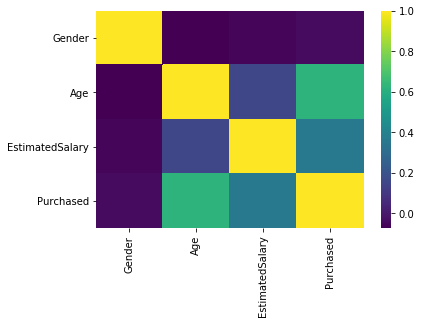

In [9]:
baza.corr()
sns.heatmap(baza.corr(), cmap="viridis")

Matrica korelacije pokazuje da atribut `Gender` ne ostvaruje značajnu korelaciju sa ostalim atributima, pa ga možemo isključiti iz daljeg procesa modeliranja.

In [10]:
# Drop Gender column
baza.drop(columns=['Gender'], inplace=True)

In [11]:
baza.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


*Razdvajanje na nezavisne promenljive i zavisnu promenljivu*

U ovom koraku koristeći poziciono indeksiranje, preciznije metodu `.iloc` iz biblioteke *pandas*, vršimo podelu kompletnog skupa  na: ulazne (nezavisne) promenljive $X$, koje služe kao ulazni parametri za obučavanje modela i na osnovu kojih model uči kako da klasifikuje nove, nepoznate uzorke, i zavisnu ciljnu promenljivu $y$. 
*Objašnjenje:*

* `baza.iloc[:, :-1]`: selektuje sve redove i sve kolone osim poslednje kako bi se izdvojile nezavisne promenljive. 

* `baza.iloc[:, -1]`: selektuje sve redove i samo poslednju kolonu kako bi se izdvojila zavisna promenljiva.

* `.values`: pretvara  strukturu podataka u *NumPy niz* kako bi se osigurala kompatibilnost sa bibliotekom *scikit-learn*.

In [12]:
X = baza.iloc[:, :-1].values
y = baza.iloc[:, -1].values

*Podela na trening i test skup*  

* `train_test_split`: funkcija koja deli ulazne podatke na trening i test podskup, vraća četiri podskupa `X_train, X_test, y_train, y_test`.
    * `X_train` i `y_train` čine trening skup na kojem model „uči“ obrasce iz podataka; `X_train` predstavlja skup nezavisnih promenljivih, dok je `y_train` skup zavisnih promenljivih (stvarne ciljne vrednosti) koje mu odgovaraju.
    * `X_test` i `y_test` služe za proveru preciznosti modela na neviđenim podacima; na osnovu `X_test` skupa model vrši predviđanja, koja se potom porede sa stvarnim ishodima u `y_test` skupu.

* `test_size`: određuje procenat ukupnog skupa podataka koji se izdvaja za testiranje. Postavljanjem `test_size = 0.25`, 25% podataka se alocira za evaluaciju, dok se preostalih 75% koristi za proces treninga.

* `random_state`: definisanjem fiksne celobrojne vrednosti postiže se reproduktivnost rezultata, jer se time osiguravaju identični ishodi pri svakom ponovnom izvršavanju koda.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

*Standardizacija numeričkih varijabli*

Iako naivni Bajes tretira svaki atribut nezavisno, standardizacija osigurava da atributi sa prirodno većim numeričkim vrednostima ne dominiraju vizuelno ili računski nad ostalima, čime se postiže stabilnije učenje i lakša interpretacija modela. Standardizacijom se numerički podaci transformišu tako da je srednja vrednost 0, a standardna devijacija 1, što obezbeđuje uporedivost svih karakteristika u skupu.

* `sc = StandardScaler()`: inicijalizuje se objekat klase `StandardScaler` pod nazivom `sc`.
* `X_train = sc.fit_transform(X_train)`: ova operacija kombinuje dva koraka:
    * `fit` identifikuje aritmetičku sredinu i standardnu devijaciju trening skupa.
    * `transform` koristi te parametre kako bi modifikovao `X_train` i doveo vrednosti na zajedničku skalu.
* `X_test = sc.transform(X_test)`: nad testnim skupom se vrši transformacija isključivo na osnovu parametara (srednje vrednosti i devijacije) koji su prethodno izračunati na trening skupu, čime se sprečava "curenje" informacija iz testnog u trening skup.

In [15]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

*Treniranje modela*  

Prvo inicijalizujemo model klase `GaussianNB` pod nazivom `klasifikator`. Pozivom metode `.fit()` na trening skupu (`X_train`, `y_train`), model prolazi kroz fazu obuke tokom koje uči da povezuje atribute sa ciljnom promenljivom. 

U ovoj fazi klasifikator identifikuje strukturu i zakonitosti u podacima, čime se formira model spreman za pouzdano predviđanje nad novim, neviđenim instancama.

In [16]:
klasifikator = GaussianNB()
klasifikator.fit(X_train, y_train)
     

GaussianNB(priors=None, var_smoothing=1e-09)

*Generisanje predviđenih vrednosti*  

- Primenom metode `.predict()` nad testnim skupom, model generiše niz predviđanja (`y_pred`). Oslanjajući se na prethodno naučene obrasce, model određuje ishode za podatke koji nisu korišćeni tokom faze obuke.

- Upotrebom metode `.reshape()`, nizovi se preoblikuju iz jednodimenzionalnog u kolonski format, čime se postiže pravilno poravnanje predviđenih i stvarnih vrednosti. Ova promena strukture je neophodna kako bi se podaci doveli u odgovarajući oblik za direktno upoređivanje i jasnu vizuelnu identifikaciju tačnosti modela.

- Primenom funkcije `np.concatenate` iz biblioteke NumPy, vrši se horizontalno spajanje predviđenih i stvarnih vrednosti u jedinstvenu matricu. Ovakav prikaz omogućava direktan uvid u performanse modela kroz neposredno poređenje svakog predviđenog ishoda sa njegovom stvarnom vrednošću.

In [17]:
y_pred = klasifikator.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]]


*Izveštaj o performansama klasifikacionog modela*   

Funkcija `classification_report` nam daje izveštaj o performansama modela za svaku klasu, kao i zbirne metrike koje ocenjuju kvalitet modela na celom skupu podataka. 

- *Makro prosek (engl. Macro Average)*  
Ova metrika daje jednaku težinu svim klasama, bez obzira na broj primera u njima. Prvo se izračunava vrednost metrike za svaku klasu pojedinačno, a zatim se računa njihova aritmetička sredina. Ovaj pristup je pogodan kada je cilj da model podjednako dobro prepoznaje i manjinske i većinske klase.

- *Težinski prosek (engl. Weighted Average)*  
Kod ove metode, broj primera u svakoj klasi direktno utiče na krajnji rezultat. Vrednost metrike za svaku klasu se ponderiše udelom te klase u ukupnom broju instanci. Metoda je korisna kod neuravnoteženih skupova podataka kada želimo da ocenimo performanse modela u skladu sa stvarnom učestalošću klasa.

- *Mikro prosek (engl. Micro Average)*  
Ova metrika posmatra ceo skup podataka kao jedinstvenu celinu. Zasniva se na ukupnom broju tačno pozitivnih, lažno pozitivnih i lažno negativnih slučajeva na nivou svih klasa. Mikro prosek pruža opštu procenu performansi, a s obzirom na to da su kod višeklasne klasifikacije mikro-preciznost, mikro-odziv i mikro-F1 identični, u novijim verzijama biblioteke ovaj prosek se iskazuje kroz tačnost.

In [18]:
print(f'Izveštaj o klasifikaciji: \n{classification_report(y_test, y_pred)}')

Izveštaj o klasifikaciji: 
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        58
           1       0.83      0.83      0.83        42

   micro avg       0.86      0.86      0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



*Prikaz matrice konfuzije pomoću toplotne mape*

Matrica konfuzije generiše se upoređivanjem stvarnih vrednosti iz test skupa sa predviđenim klasama i čuva se pod nazivom `matrica_konfuzije`. Ova matrica je vizuelizovana pomoću toplotne mape, koja jasno razdvaja tačne klasifikacije od grešaka kroz dve ose: vertikalna $Y$-osa predstavlja stvarne vrednosti, dok horizontalna $X$-osa prikazuje predviđene vrednosti.

Glavna dijagonala matrice prikazuje broj tačnih predviđanja, dok vrednosti van glavne dijagonale ukazuju na broj grešaka i precizno lociraju tip konfuzije klasifikatora.

<AxesSubplot:>

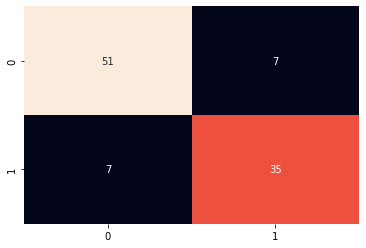

In [26]:
matrica_konfuzije = confusion_matrix(y_test, y_pred)
sns.heatmap(matrica_konfuzije, annot=True, cbar=False)

*Grafički prikaz tačnosti modela*

Pošto su podaci prethodno bili skalirani, koristi se funkcija `inverse_transform` kako bi se vrednosti vratile u originalne jedinice (godine i plata). Na ovaj način se podaci vraćaju u svoje izvorne opsege, pa umesto apstraktnih skaliranih vrednosti (npr. 0.5) na grafiku možemo videti realne iznose poput 50.000 (vrednost plate).

In [29]:
X_set, y_set = sc.inverse_transform(X_train), y_train

*Vizuelizacija mreže tačaka*  

U nastavku se kreira mreža tačaka koja pokriva celokupan koordinatni sistem kako bi model za svaku tačku predvideo pripadnost određenoj klasi. Matrice `X1` i `X2` redstavljaju sve moguće kombinacije vrednosti prve i druge osobine, kao što su starost i procenjena plata. Korišćenjem izraza `X_set[:, 0]` i `X_set[:, 1]` pristupamo vrednostima ovih karakteristika u skupu podataka. 

- Proširenjem opsega na obe ose (`-10/+10` za prvu osobinu i `-1000/+1000` za drugu) kreiramo dovoljno prostora da se jasno iscrta granica odlučivanja.

- `np.arange(start, stop, step)`: kreira niz vrednosti sa zadatim korakom i zadatim početnom i krajnjom tačkom.  

- `np.meshgrid` generiše dve koordinatne matrice, `X1` i `X2`, koje definišu mrežu tačaka na grafiku. 

In [30]:
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))

*Vizuelizacija granice odlučivanja*


-  *Bojenje pozadine (`plt.contourf`)*  
Ova funkcija vizuelizuje granice klasifikacije tako što boji pozadinu grafikona na osnovu predviđanja modela:
    - `X1.ravel(), X2.ravel()`: pretvaraju dvodimenzionalne matrice u jednodimenzionalne nizove kako bi se kreirala lista svih koordinata u prostoru.
    - `sc.transform(...)`: skalira tačke mreže kroz isti proces skaliranja kao i podaci za obuku, jer je model obučen na skaliranim podacima.  
    - `klasifikator.predict(...).reshape(X1.shape)`: model predviđa klasu za svaku tačku, a `reshape` reoblikuju u format matrice koji odgovara dimenzijama grafikona.
    - `alpha = 0.8` – kontroliše intenzitet providnosti 
    - `cmap = ListedColormap(...)`: definiše boje; crvena za klasu 0, zelena za klasu 1.

-  *Definisanje granica osa (`plt.xlim` i `plt.ylim`)*  
Ograničavaju opseg horizontalne i vertikalne ose tačno prema koordinatama generisane mreže tačaka, čime se osigurava da se grafikon prikazuje u tačnom opsegu mreže tačaka.

-  *Iscrtavanje stvarnih podataka (`plt.scatter`)*  
Dok `contourf` boji pozadinu, `scatter` crta stvarne tačke iz skupa podataka:
    - `enumerate(np.unique(y_set))`: prolazi kroz sve jedinstvene klase (0 i 1).  
    - `X_set[y_set == j, 0]`: filtrira i crta tačke koje pripadaju trenutnoj klasi `j`.  
    - `label = j`: dodeljuje ime grupi tačaka za legendu.

-  *Labeliranje i prikaz*  
    - `plt.legend()`: prikazuje tabelu koja objašnjava boje (npr. crveno = nije kupio, zeleno = kupio).  
    - `plt.xlabel` / `plt.ylabel`: postavlja nazive osa (npr. Godine i Plata).  
    - `plt.show()`: generiše i prikazuje finalni grafikon.


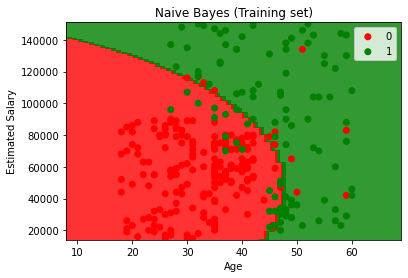

In [31]:
plt.contourf(X1, X2, klasifikator.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.8, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = [ListedColormap(('red', 'green'))(i)] * len(X_set[y_set == j, 0]), label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

Vizuelizacija granice odlučivanja prikazuje kako je klasifikator podelio prostor obeležja:
* crvena zona obuhvata deo površine koji klasifikator označava kao klasu 0 (korisnik nije izvršio kupovinu)
* zelena zona obuhvata deo površine koji klasifikator označava kao klasu 1 (korisnik je izvršio kupovinu)

Na grafiku se primećuje da pojedine zelene tačke pripadaju crvenoj zoni i obrnuto, što predstavlja instance koje je model pogrešno predvideo. Ipak, na osnovu opšteg prikaza vidimo da je klasifikator većinu tačaka ispravno klasifikovao, uspešno prateći trendove u podacima.

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


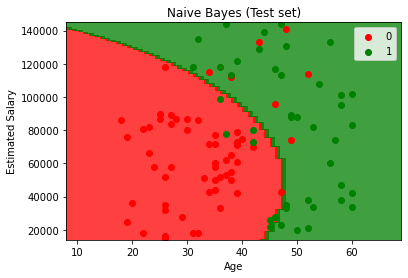

In [32]:

# Visualize prediction results on test set
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, klasifikator.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()
     

*Analiza granica odlučivanja*

Na osnovu vizuelizacije trening i test skupa, mogu se izvući sledeći zaključci o radu modela:

* Nelinearna granica odlučivanja: Iako je naivni Bajes jednostavan model, vidimo da je formirao zakrivljenu (nelinearnu) granicu. To je posledica pretpostavke o Gausovoj raspodeli atributa, pri čemu model procenjuje srednje vrednosti i varijanse po klasama, što dovodi do eliptičnih ili paraboličnih granica.

* Dobra sposobnost generalizacije: Granice odlučivanja na trening i test skupu su veoma slične, što ukazuje na odsustvo preprilagođavanja. Model uspešno hvata opšti obrazac u podacima: mlađi korisnici sa nižim primanjima češće pripadaju klasi 0 (crvena zona), dok stariji ili oni sa višim primanjima češće pripadaju klasi 1 (zelena zona).

* Prisustvo grešaka u klasifikaciji: Na test skupu uočava se manji broj pogrešno klasifikovanih primera. To je očekivano, jer u realnim podacima često dolazi do preklapanja klasa, pa fiksna granica ne može savršeno razdvojiti sve instance.

* Uticaj atributa: Oba atributa, starost i procenjena plata, imaju vidljiv uticaj na odluku modela. Sa porastom njihovih vrednosti raste i verovatnoća pripadnosti klasi 1.

## Hajde da proverimo znanje! 🧠

Odgovori na sledeća pitanja kako bi utvrdio svoje razumevanje algoritma.

:::{admonition} Kviz 1.
:class: hint 
Na kojoj se ključnoj pretpostavci zasniva Naivni Bajesov klasifikator?  
a) Pretpostavci o normalnoj raspodeli svih ulaznih varijabli.  
b) Pretpostavci o uslovnoj nezavisnosti atributa unutar svake klase.  
c) Pretpostavci o jednakoj zastupljenosti svih klasa u skupu podataka.  
d) Pretpostavci da model obrađuje isključivo binarne podatke.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** b) Pretpostavci o uslovnoj nezavisnosti atributa unutar svake klase.
```
:::

:::{admonition} Kviz 2
:class: hint

Koji tip Naivnog Bajesovog klasifikatora je pogodan za neprekidne numeričke podatke?  
a) MultinomialNB  
b) GaussianNB   
c) BernoulliNB  
d) CategoricalNB  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** b) GaussianNB
```
:::

:::{admonition} Kviz 3
:class: hint

Koja je od navedenih tvrdnji o Naivnom Bajesovom klasifikatoru tačna?  

a) Model je ograničen isključivo na rad sa binarnim klasama.  
b) Zahteva iscrpno podešavanje hiperparametara kako bi bio efikasan.  
c) Veoma je efikasan na malim skupovima podataka i ne zahteva kompleksno podešavanje parametara.  
d) Algoritam nije primenljiv na numeričke (kontinuirane) tipove podataka.  

```{admonition} Odgovor:  
:class: dropdown
```python
**Odgovor:** c) Veoma je efikasan na malim skupovima podataka i ne zahteva kompleksno podešavanje parametara. 
```
:::

:::{admonition} Kviz 4
:class: hint

Kojom se tehnikom u okviru Naivnog Bajesovog algoritma rešava problem nulte verovatnoće kod atributa koji se nisu pojavili u skupu za obuku?  

a) Standardizacija  
b) Laplasovo zaglađivanje (engl. Laplace smoothing)  
c) Skaliranje osobina  
d) Normalizacija podataka  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** b) Laplasovo zaglađivanje (engl. Laplace smoothing)  
```
:::

:::{admonition} Kviz 5
:class: hint

Na koji način GaussianNB izračunava verovatnoću kontinuirane promenljive za koju se pretpostavlja da prati normalnu raspodelu?  

a) Sabiranjem svih vrednosti unutar date klase.  

b) Primenom Gausove (normalne) distribucije koristeći srednju vrednost i standardnu devijaciju te klase.  

c) Automatskom diskretizacijom podataka u binarne kategorije.  

d) Isključivanjem kontinuiranih promenljivih iz procesa modelovanja.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** b) Primenom Gausove (normalne) distribucije koristeći srednju vrednost i standardnu devijaciju te klase.  
```
:::

:::{admonition} Kviz 6
:class: hint

Koji od navedenih Naivnih Bajesovih klasifikatora je specijalizovan za rad sa podacima koji prate Bernulijevu raspodelu, gde su obeležja binarni vektori (0 i 1)?  

a) GaussianNB  

b) MultinomialNB  

c) BernoulliNB  

d) CategoricalNB  
```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) BernoulliNB  
```
:::

:::{admonition} Kviz 7
:class: hint

Koja je primarna uloga Laplasovog zaglađivanja (Laplace smoothing) u okviru Naivnog Bajesovog algoritma?  

a) Transformacija kontinuiranih obeležja u diskretne kategorije.  

b) Standardizacija numeričkih podataka radi lakšeg poređenja različitih skala.  

c) Dodavanje male konstante učestalostima atributa kako bi se sprečilo da nepojavljivanje neke kombinacije rezultira nultom verovatnoćom.  

d) Automatsko balansiranje težina klasa u neizbalansiranim skupovima podataka.  
```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Dodavanje male konstante učestalostima atributa kako bi se sprečilo da nepojavljivanje neke kombinacije rezultira nultom verovatnoćom.
```
:::

## Literatura

```{bibliography}
:style: unsrt
:filter: docname in docnames